# Name : Ankit Vaghela
# USN : 1AUA23BCS009

# Lab 7
## Batch Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-Batch
## Gradient Descent using TensorFlow

In [1]:
import numpy as np
import tensorflow as tf
np.random.seed(42)
X = np.random.rand(1000, 1)
y = 3 * X + 2 + np.random.randn(1000, 1) * 0.1

In [2]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])
loss_fn = tf.keras.losses.MeanSquaredError()

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Experiment 1: Batch Gradient Descent

In [3]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_losses = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = model(X)                 
        loss = loss_fn(y, y_pred)          
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    print(f"Epoch {epoch + 1}, Loss: {loss.numpy()}")
    batch_losses.append(loss.numpy())
weights = model.layers[0].get_weights()
print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 13.653759002685547
Epoch 2, Loss: 7.750725746154785
Epoch 3, Loss: 4.441472053527832
Epoch 4, Loss: 2.5852065086364746
Epoch 5, Loss: 1.5429069995880127
Epoch 6, Loss: 0.9566213488578796
Epoch 7, Loss: 0.6258395314216614
Epoch 8, Loss: 0.43824297189712524
Epoch 9, Loss: 0.33091437816619873
Epoch 10, Loss: 0.2686086893081665
Epoch 11, Loss: 0.2315817028284073
Epoch 12, Loss: 0.20877183973789215
Epoch 13, Loss: 0.19398155808448792
Epoch 14, Loss: 0.1837376058101654
Epoch 15, Loss: 0.17609314620494843
Epoch 16, Loss: 0.16995607316493988
Epoch 17, Loss: 0.1647133231163025
Epoch 18, Loss: 0.16002017259597778
Epoch 19, Loss: 0.15568216145038605
Epoch 20, Loss: 0.15158911049365997

Learned Weight: [[1.7179296]]
Learned Bias: [2.672365]


# Experiment 2: Stochastic Gradient Descent (SGD)

In [4]:
epochs = 20
n = len(X)
sgd_losses = []
for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    total_loss = 0
    for i in range(n):
        x_i = X_shuffled[i:i+1]
        y_i = y_shuffled[i:i+1]
        with tf.GradientTape() as tape:
            y_pred = model(x_i)
            loss = loss_fn(y_i, y_pred)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        total_loss += loss.numpy()
    print(f"Epoch {epoch+1}, Loss: {total_loss/n}")
    sgd_losses.append(loss.numpy())
weights = model.layers[0].get_weights()
print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.017055345699191093
Epoch 2, Loss: 0.011345012113451958
Epoch 3, Loss: 0.011397575959563255
Epoch 4, Loss: 0.011113918386399746
Epoch 5, Loss: 0.011370019987225533
Epoch 6, Loss: 0.011288768611848354
Epoch 7, Loss: 0.011438586749136448
Epoch 8, Loss: 0.0110311945900321
Epoch 9, Loss: 0.011422380805015564
Epoch 10, Loss: 0.011079758405685425
Epoch 11, Loss: 0.011308764107525349
Epoch 12, Loss: 0.011478235945105553
Epoch 13, Loss: 0.01133654173463583
Epoch 14, Loss: 0.01112370751798153
Epoch 15, Loss: 0.011123890057206154
Epoch 16, Loss: 0.011465905234217644
Epoch 17, Loss: 0.011085678823292255
Epoch 18, Loss: 0.011331060901284218
Epoch 19, Loss: 0.011387364007532597
Epoch 20, Loss: 0.011322776786983013

Learned Weight: [[2.950063]]
Learned Bias: [2.0042994]


# Experiment 3: Mini-Batch Gradient Descent

In [5]:
epochs = 20
batch_size = 32
n = len(X)

mini_batch_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.01257121842354536
Epoch 2, Loss: 0.021400216966867447
Epoch 3, Loss: 0.005173699930310249
Epoch 4, Loss: 0.006892520003020763
Epoch 5, Loss: 0.002740241587162018
Epoch 6, Loss: 0.0030989511869847775
Epoch 7, Loss: 0.01533571071922779
Epoch 8, Loss: 0.005459874868392944
Epoch 9, Loss: 0.016151783987879753
Epoch 10, Loss: 0.007315133698284626
Epoch 11, Loss: 0.01233942061662674
Epoch 12, Loss: 0.00637345016002655
Epoch 13, Loss: 0.009358935989439487
Epoch 14, Loss: 0.014066587202250957
Epoch 15, Loss: 0.005975005682557821
Epoch 16, Loss: 0.009902623482048512
Epoch 17, Loss: 0.00806879997253418
Epoch 18, Loss: 0.005985008552670479
Epoch 19, Loss: 0.014088811352849007
Epoch 20, Loss: 0.014355495572090149

Learned Weight: [[2.9862046]]
Learned Bias: [2.0226543]


# Comparative Chart: ALL three methods

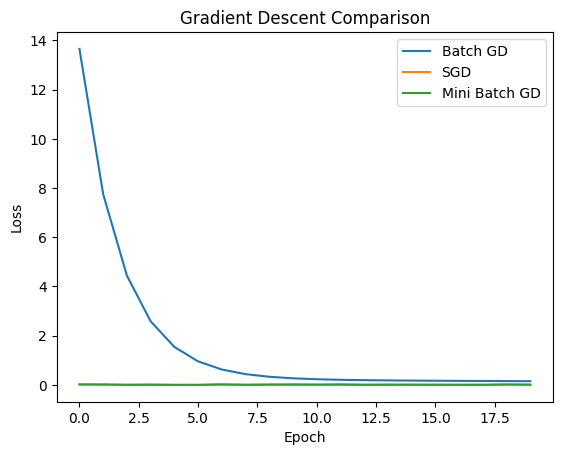

In [6]:
import matplotlib.pyplot as plt
plt.plot(batch_losses,label="Batch GD")
plt.plot(sgd_losses,label="SGD")
plt.plot(mini_batch_losses,label="Mini Batch GD")
plt.title("Gradient Descent Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Knowledge Check (Conceptual Understanding)

# 1. Why does Batch Gradient Descent have a smooth loss curve but slow convergence?

**Batch Gradient Descent**

Batch Gradient Descent calculates the gradient using the entire training dataset before updating the model parameters. Because it uses all data points, the gradient estimate is highly accurate and stable. This results in a smooth loss curve during training.

However, since the algorithm processes the whole dataset in every iteration, it is computationally expensive and time-consuming. As a result, parameter updates occur less frequently, leading to slower convergence, especially for large datasets.

**Key Points:**

* Uses the entire dataset to compute gradients
* Produces a smooth and stable loss curve
* Slow convergence due to heavy computation


# 2. What causes fluctuations in the loss function when using SGD?

**Stochastic Gradient Descent (SGD)**

Stochastic Gradient Descent (SGD) updates model parameters using one training example at a time instead of the full dataset. Since each data point may suggest a different direction for optimization, the computed gradient can vary significantly between updates.

Due to this randomness, the loss value may increase or decrease irregularly, leading to a fluctuating or zig-zag loss curve. While this introduces noise, it can help the model escape local minima and often leads to faster initial convergence.

**Key Points:**

* Uses a single data sample per update
* Gradient estimate is noisy
* Produces a zig-zag or fluctuating loss curve
* Faster updates but less stable than batch gradient descent


# 3. Why is Mini-Batch Gradient Descent preferred for training deep neural networks?

**Mini-Batch Gradient Descent**

Mini-Batch Gradient Descent combines the advantages of both Batch Gradient Descent and Stochastic Gradient Descent. Instead of using the entire dataset or a single sample, it updates model parameters using a small subset of data called a mini-batch.

This approach offers a balance between stability and efficiency—providing smoother updates than SGD while being significantly faster than Batch Gradient Descent. It is also well-suited for GPU acceleration and parallel processing, making it the preferred method for training deep learning models.

**Key Points:**

* Uses small batches (e.g., 32, 64, 128 samples)
* More stable than SGD and faster than Batch Gradient Descent
* Efficient for large datasets and deep neural networks


# 4. What happens if the batch size is increased to the full dataset?

**Mini-Batch = Full Batch Case**

If the batch size becomes equal to the entire training dataset, Mini-Batch Gradient Descent effectively becomes Batch Gradient Descent.

In this situation, the gradient calculation is highly accurate, resulting in a smooth loss curve. However, since each iteration processes the entire dataset, the computation becomes expensive and training slows down.

**Key Points:**

* Equivalent to Batch Gradient Descent
* Produces a smooth loss curve
* Higher computational cost and slower updates


# 5. How does shuffling the dataset affect SGD and Mini-Batch GD?

**Shuffling the Dataset**

Shuffling the dataset means randomly rearranging the order of training samples before each epoch.

For SGD and Mini-Batch Gradient Descent, shuffling ensures that each update is based on randomly distributed data samples. This prevents the model from learning unintended patterns from the data order and improves the overall training process.

Without shuffling, similar samples may appear consecutively, which can lead to biased updates and poor convergence.

**Key Points:**

* Improves randomness during training
* Prevents bias caused by data ordering
* Leads to better convergence and generalization


# Exercise 1: Effect of Learning Rate
# Objective: To study the effect of learning rate on convergence behavior.
# Task: - Train the same model using Mini-Batch Gradient
# Descent - Use learning rates:
# 0.001, 0.01, and 0.1 - Plot loss vs epochs for each case(1) Learning Rate = 0.001

In [7]:
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 32
n = len(X)

mini_batch1_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch1_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.008653325960040092
Epoch 2, Loss: 0.0035132316406816244
Epoch 3, Loss: 0.003719029016792774
Epoch 4, Loss: 0.0038667155895382166
Epoch 5, Loss: 0.004644549451768398
Epoch 6, Loss: 0.009226291440427303
Epoch 7, Loss: 0.017734277993440628
Epoch 8, Loss: 0.009077155962586403
Epoch 9, Loss: 0.013107424601912498
Epoch 10, Loss: 0.005999931134283543
Epoch 11, Loss: 0.010132644325494766
Epoch 12, Loss: 0.006791589315980673
Epoch 13, Loss: 0.011131956242024899
Epoch 14, Loss: 0.009859712794423103
Epoch 15, Loss: 0.01478529442101717
Epoch 16, Loss: 0.006376633420586586
Epoch 17, Loss: 0.014771375805139542
Epoch 18, Loss: 0.0131386648863554
Epoch 19, Loss: 0.004444657824933529
Epoch 20, Loss: 0.003985179588198662

Learned Weight: [[2.984328]]
Learned Bias: [2.0188522]


# (2) Learning Rate = 0.01

In [8]:
learning_rate = 0.01
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 32
n = len(X)

mini_batch2_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch2_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.010615304112434387
Epoch 2, Loss: 0.0113137885928154
Epoch 3, Loss: 0.012254036962985992
Epoch 4, Loss: 0.00736588891595602
Epoch 5, Loss: 0.014693673700094223
Epoch 6, Loss: 0.005834610667079687
Epoch 7, Loss: 0.016050616279244423
Epoch 8, Loss: 0.019040081650018692
Epoch 9, Loss: 0.005918417125940323
Epoch 10, Loss: 0.010035708546638489
Epoch 11, Loss: 0.005463413428515196
Epoch 12, Loss: 0.006031490862369537
Epoch 13, Loss: 0.005915296263992786
Epoch 14, Loss: 0.013357914984226227
Epoch 15, Loss: 0.010316019877791405
Epoch 16, Loss: 0.014981113374233246
Epoch 17, Loss: 0.012226385064423084
Epoch 18, Loss: 0.009669870138168335
Epoch 19, Loss: 0.01131906546652317
Epoch 20, Loss: 0.009014658629894257

Learned Weight: [[2.9842672]]
Learned Bias: [2.0169683]


# (3) Learning Rate = 0.1

In [9]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 32
n = len(X)

mini_batch3_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch3_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.002290524309501052
Epoch 2, Loss: 0.009215141646564007
Epoch 3, Loss: 0.005207843147218227
Epoch 4, Loss: 0.0036412090994417667
Epoch 5, Loss: 0.007570459973067045
Epoch 6, Loss: 0.011232372373342514
Epoch 7, Loss: 0.011145495809614658
Epoch 8, Loss: 0.003928962163627148
Epoch 9, Loss: 0.013080725446343422
Epoch 10, Loss: 0.0015047763008624315
Epoch 11, Loss: 0.0069866180419921875
Epoch 12, Loss: 0.005855676252394915
Epoch 13, Loss: 0.010165128856897354
Epoch 14, Loss: 0.007211944088339806
Epoch 15, Loss: 0.008884655311703682
Epoch 16, Loss: 0.004577110055834055
Epoch 17, Loss: 0.0210702084004879
Epoch 18, Loss: 0.012240414507687092
Epoch 19, Loss: 0.007625022903084755
Epoch 20, Loss: 0.01149874646216631

Learned Weight: [[2.990177]]
Learned Bias: [2.0284846]


# Comparative Chart

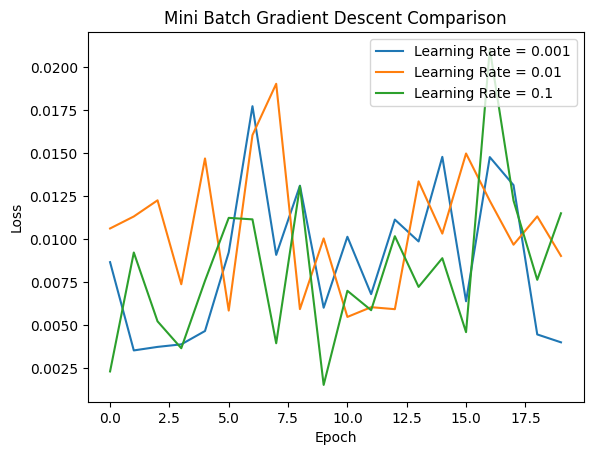

In [10]:
plt.plot(mini_batch1_losses,label="Learning Rate = 0.001")
plt.plot(mini_batch2_losses,label="Learning Rate = 0.01")
plt.plot(mini_batch3_losses,label="Learning Rate = 0.1")
plt.title("Mini Batch Gradient Descent Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Questions:
# 1. Which learning rate converges fastest? = "Learning Rate = 0.01"
# 2. Which learning rate causes instability? = "Learning Rate = 0.001"
# 3. What happens if the learning rate is too small? ="Gradient Can Converge to 0"
# Exercise 2: Effect of Batch Size
# Objective: To analyze how batch size influences training stability and speed.
# Task: - Train the model using batch sizes: 1, 16, 64, and full dataset - Observe loss behavior

In [11]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 1
n = len(X)

mini_batch10_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch10_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.002518722089007497
Epoch 2, Loss: 0.0017439147923141718
Epoch 3, Loss: 0.0003759392420761287
Epoch 4, Loss: 0.016080189496278763
Epoch 5, Loss: 0.002522720256820321
Epoch 6, Loss: 0.08072801679372787
Epoch 7, Loss: 0.013162288814783096
Epoch 8, Loss: 0.002269418677315116
Epoch 9, Loss: 0.08257361501455307
Epoch 10, Loss: 0.004350901115685701
Epoch 11, Loss: 0.014746441505849361
Epoch 12, Loss: 0.027192266657948494
Epoch 13, Loss: 0.008909321390092373
Epoch 14, Loss: 2.780554723358364e-06
Epoch 15, Loss: 0.01107171643525362
Epoch 16, Loss: 0.0015266985865309834
Epoch 17, Loss: 0.008207066915929317
Epoch 18, Loss: 0.006280615925788879
Epoch 19, Loss: 0.01002555526793003
Epoch 20, Loss: 0.004398524295538664

Learned Weight: [[2.9826624]]
Learned Bias: [1.9966229]


In [12]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 16
n = len(X)

mini_batch20_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch20_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.01757919043302536
Epoch 2, Loss: 0.003202526830136776
Epoch 3, Loss: 0.014569446444511414
Epoch 4, Loss: 0.00423654867336154
Epoch 5, Loss: 0.0027350112795829773
Epoch 6, Loss: 0.0056223198771476746
Epoch 7, Loss: 0.004682657774537802
Epoch 8, Loss: 0.023881524801254272
Epoch 9, Loss: 0.016879595816135406
Epoch 10, Loss: 0.007530895061790943
Epoch 11, Loss: 0.00551729928702116
Epoch 12, Loss: 0.008791571483016014
Epoch 13, Loss: 0.009106199257075787
Epoch 14, Loss: 0.007482713554054499
Epoch 15, Loss: 0.007391674444079399
Epoch 16, Loss: 0.008349074050784111
Epoch 17, Loss: 0.008852032944560051
Epoch 18, Loss: 0.023695439100265503
Epoch 19, Loss: 0.01346680149435997
Epoch 20, Loss: 0.009601300582289696

Learned Weight: [[2.9828439]]
Learned Bias: [2.0086684]


In [13]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = 64
n = len(X)

mini_batch30_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch30_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.013881852850317955
Epoch 2, Loss: 0.007492943201214075
Epoch 3, Loss: 0.009033197537064552
Epoch 4, Loss: 0.010388640686869621
Epoch 5, Loss: 0.01147262193262577
Epoch 6, Loss: 0.010614657774567604
Epoch 7, Loss: 0.00920434296131134
Epoch 8, Loss: 0.014909641817212105
Epoch 9, Loss: 0.008214028552174568
Epoch 10, Loss: 0.009963272139430046
Epoch 11, Loss: 0.010872622951865196
Epoch 12, Loss: 0.009685024619102478
Epoch 13, Loss: 0.00968249887228012
Epoch 14, Loss: 0.009072503075003624
Epoch 15, Loss: 0.008618706837296486
Epoch 16, Loss: 0.007979701273143291
Epoch 17, Loss: 0.012457798235118389
Epoch 18, Loss: 0.012283526360988617
Epoch 19, Loss: 0.009268120862543583
Epoch 20, Loss: 0.008743403479456902

Learned Weight: [[2.984803]]
Learned Bias: [2.0165992]


In [14]:
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

epochs = 20
batch_size = len(X)
n = len(X)

mini_batch40_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            loss = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
    mini_batch40_losses.append(loss.numpy())

weights = model.layers[0].get_weights()

print("\nLearned Weight:", weights[0])
print("Learned Bias:", weights[1])

Epoch 1, Loss: 0.009750233963131905
Epoch 2, Loss: 0.009750002063810825
Epoch 3, Loss: 0.009749872609972954
Epoch 4, Loss: 0.009749798104166985
Epoch 5, Loss: 0.009749756194651127
Epoch 6, Loss: 0.00974973477423191
Epoch 7, Loss: 0.009749721735715866
Epoch 8, Loss: 0.009749713353812695
Epoch 9, Loss: 0.009749707765877247
Epoch 10, Loss: 0.009749704040586948
Epoch 11, Loss: 0.0097497021779418
Epoch 12, Loss: 0.009749701246619225
Epoch 13, Loss: 0.009749699383974075
Epoch 14, Loss: 0.009749699383974075
Epoch 15, Loss: 0.0097496984526515
Epoch 16, Loss: 0.009749699383974075
Epoch 17, Loss: 0.0097496984526515
Epoch 18, Loss: 0.009749697521328926
Epoch 19, Loss: 0.009749696590006351
Epoch 20, Loss: 0.009749696590006351

Learned Weight: [[2.9849644]]
Learned Bias: [2.017243]


import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
plt.plot(mini_batch10_losses,label="Batch Size = 1")
plt.plot(mini_batch20_losses,label="Batch Size = 16")
plt.plot(mini_batch30_losses,label="Batch Size = 64")
plt.plot(mini_batch40_losses,label="Batch Size = Full Dataset")
plt.title("Mini Batch Gradient Descent Comparison For Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Questions:
# 1. Which batch size behaves like SGD? 

**1**

# 2. Which batch size behaves like Batch Gradient Descent? 

**Full Dataset**

# 3. Which batch size gives the best balance between speed and stability? 

**16 & 64**